# Image Processing SoSe 2026 - Assignment - 01

### Deadline is Thursday, 23.04.2026 at 11:55 a.m.

#### Students: NAME1 NAME2

Please solve the assignments together with one or two partners. Do not copy solutions. Do not use any A.I. tools unless explicitly told so.

Make sure the code runs without errors, when clicking `Kernel` -> `Restart Kernel & Run All Cells`. Then save the notebook and upload your submission. Code which does not run will not receive the points.

## Introduction to Python / Numpy

* [Learn Python in 15 minutes](https://learnxinyminutes.com/docs/python3/): We will use Python 3.
* [Numpy for Matlab Users](https://docs.scipy.org/doc/numpy/user/numpy-for-matlab-users.html#general-purpose-equivalents)
* [Numpy Quickstart](https://docs.scipy.org/doc/numpy/user/quickstart.html)

## Libraries

We will use the following libraries:

* matplotlib
* numpy
* scipy
* Pillow


# Exercise 1-0 - Setup Development Environment - [1 Point]

Install the following dependencies using pip install: jupyterlab numpy scipy matplotlib

In [1]:
#!{sys.executable} -m pip install jupyterlab numpy scipy matplotlib

(512, 512, 3)
uint8


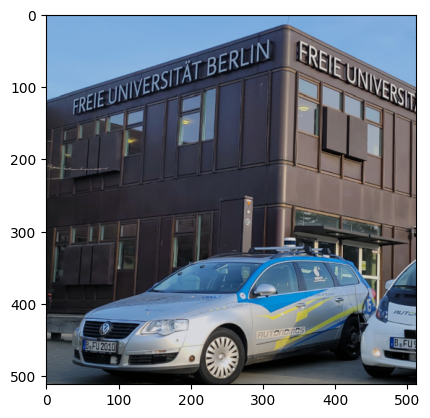

In [2]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

img = mpimg.imread('imgs/01-autonomos.jpeg' , )
plt.imshow(img)

print(img.shape)
print(img.dtype)




Now normalize each channel so that each value lies in the interval of [0, 1]:

float64


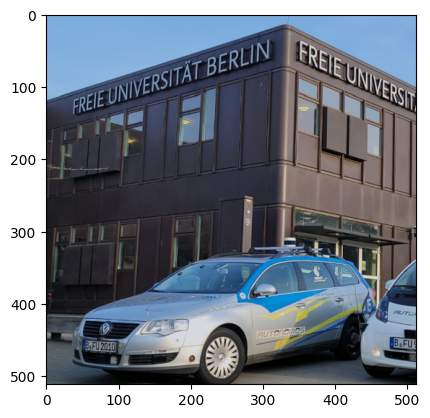

In [3]:
img = img / 255
print(img.dtype)

plt.imshow(img)

## Exercise 1-1 - Plot -       [3 Points]

Plot the R, G and B channels separately. Plot them as three separate single channel gray-images.

(512, 512, 3)


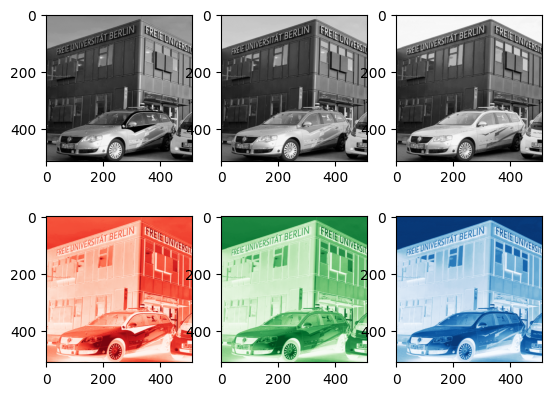

In [4]:
fig, ax = plt.subplots(2, 3)
print(img.shape)
ax[0, 0].imshow(img[:, :, 0], cmap='gray')
ax[0, 1].imshow(img[:, :, 1], cmap='gray')
ax[0, 2].imshow(img[:, :, 2], cmap='gray')
ax[1, 0].imshow(img[:, :, 0], cmap='Reds')
ax[1, 1].imshow(img[:, :, 1], cmap='Greens')
ax[1, 2].imshow(img[:, :, 2], cmap='Blues')

## Exercise 1-2 - XYZ to xy [3 Points]

Implement the `XYZ_to_xy` function where x and y indicate the chromaticity of a color. x shall be calculated as X / (X+Y+Z) and y as Y / (X+Y+Z).


In [17]:
def XYZ_to_xy(x):
    img = [[[0,0,0] if (row[0] + row[1] + row[2]) == 0 else 
            [row[0] / (row[0] + row[1] + row[2]), 
             row[1] / (row[0] + row[1] + row[2]), 
             1 - (row[0] / (row[0] + row[1] + row[2]) + row[1] / (row[0] + row[1] + row[2]))] for row in line] for line in x]
    return img

Plot the image and its new x and y components.

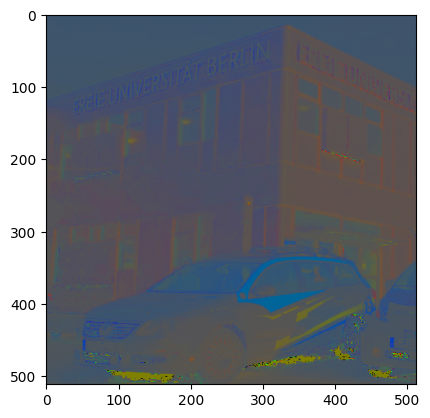

In [18]:
img_as_xy = XYZ_to_xy(img)

plt.imshow(img_as_xy)

## Exercise 1-3 - Calculation [3 Points]

In the figure below you can see the [CIE-XYZ](https://de.wikipedia.org/wiki/CIE-Normvalenzsystem) color space.
![](https://upload.wikimedia.org/wikipedia/commons/4/49/CIE-Normfarbtafel.png)

What are the approximate x,y,z values for the following Adobe RGB colors:
* `(0, 0.5, 0.5)`
* `(0.33, 0.33, 0.33)`

A sodium-vapor lamp shines with double the intensity of a mercury-vapor lamp
. The light from the sodium lamp only contains
the spectral line at `589,00nm` and the light from the mercury lamp only the
spectral line at `435,83 nm`.

What color does a human experience? What are the approximate x,y,z values?


**Color 1**
```
Color 1 = (x,y,z) = (0, 0.5, 0.5)

X + Y + Z   = 0 + 0.5 + 0.5
            = 1

x   = X / (X + Y + Z)
    = 0 / 1
    = 0

y   = Y / (X + Y + Z)
    = 0.5 / 1
    = 0.5

z   = 1 - (x + y)
    = 1 - (0 + 0.5)
    = 0.5
```

**Color 2**
```
Color 2 = (x,y,z) ≈ (0.33, 0.33, 0.33)

X + Y + Z   = 0.33 + 0.33 + 0.33
            = 0.99 
            ≈ 1

x   = X / (X + Y + Z)
    = 0.33 / 1
    = 0.33

y   = Y / (X + Y + Z)
    = 0.33 / 1
    = 0.33

z   = 1 - (x + y)
    = 1 - (0.33 + 0.33)
    = 0.34
    ≈ 0.33
```

### 3)
Ich konnte keine Funktion finden, die einer Wellenlänge rgb- oder xyz-Werte zuordnet, also kann ich nur aus den Abbildungen der Graphen approximieren.

```
435,83 nm   -> (R,G,B)  ~ (0.3, 0, 1.6)
            -> (X,Y,Z)  ~ (0.16, 0, 0.84)

589,00 nm   -> (R,G,B)  ~ (1.0, 0.8, 0)
            -> (X,Y,Z)  ~ (0.56, 0.44, 0)    


(0.3, 0, 1.6) + 2 * (1.0, 0.8, 0)   = (2.3, 1.6, 1.6)
                                    = (1, 0.9, 0.9) # /2,3
                                    = (0.42, 0.29, 0.29) # normalized

(0.16, 0, 0.84) + 2 * (0.56, 0.44, 0)   = (1.28, 0.88, 0.84) 
                                        = (1, 0.69, 0.66) # /1.28
                                        = (0.43, 0.29, 0.28) # normalized
                                        = (X,Y,Z)

```

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.6].


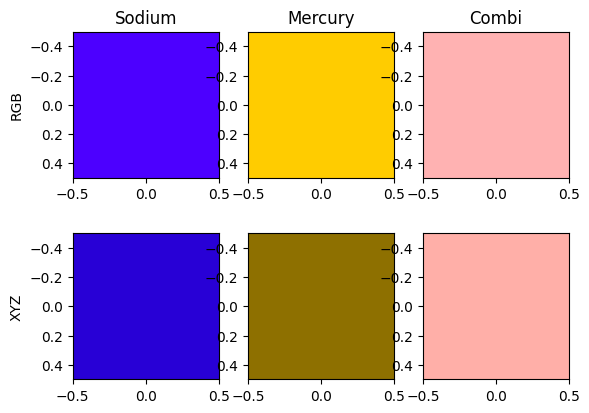

In [33]:
fig, ax = plt.subplots(2,3)

sodium_rgb = [[[0.3, 0, 1.6]]]
mercury_rgb = [[[1.0, 0.8, 0]]]
combi_rgb = [[[1, 0.7, 0.7]]]

sodium_xyz = [[[0.16, 0, 0.84]]]
mercury_xyz = [[[0.56, 0.44, 0]]]
combi_xyz = [[[1, 0.69, 0.66]]]

ax[0,0].imshow(sodium_rgb)
ax[0,1].imshow(mercury_rgb)
ax[0,2].imshow(combi_rgb)
ax[1,0].imshow(sodium_xyz)
ax[1,1].imshow(mercury_xyz)
ax[1,2].imshow(combi_xyz)

ax[0,0].set_title('Sodium')
ax[0,1].set_title('Mercury')
ax[0,2].set_title('Combi')
ax[0,0].set_ylabel('RGB')
ax[1,0].set_ylabel('XYZ')

plt.show()

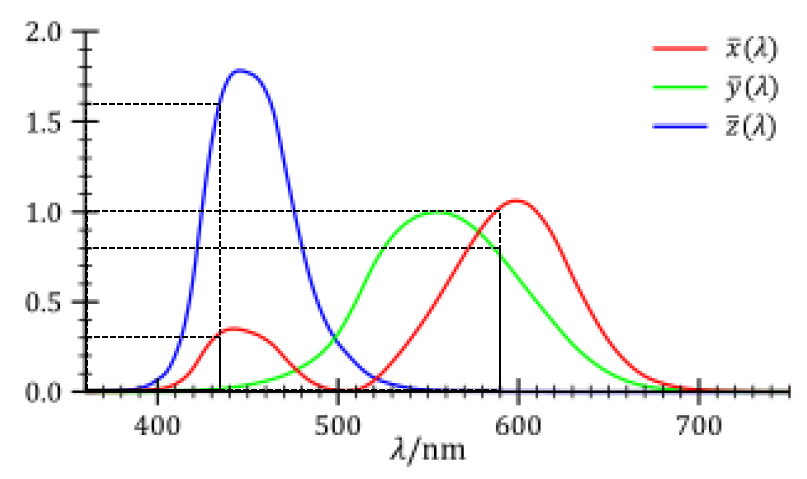